#**Problem Set III: Mecánica Celeste:** El problema de los 3 cuerpos

<div align="left">

### Juliana Ruiz Montoya
### 1007435437

**NOTA:** En este cuaderno se resolverán computacionalmente los puntos 2, 3 y 4 del problem set 3.

In [82]:
!pip install -Uq pymcel

In [153]:
# Librerías

import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

**2. Puntos colineales de Lagrange.**

Calcule numéricamente la ubicación de los puntos colineales de Lagrange para un valor de $α = 0.3$ resolviendo la ecuación:

$$ x-(1-α) \frac{x -x_1}{|x-x_1|^3} - α \frac{x -x_2}{|x-x_2|^3} = 0 $$

Primero se define la ecuación para puntos colineales de Lagrange, se establece un $α = 0.3$ y se establecen los puntos $x_1 = -α$ y $x_2 = 1-α$ que corresponden a los cuerpos del sistema, siendo el más masivo $x_1$.

In [84]:
def funcion_puntos_colineales(x, alfa):
    x1, x2 = -alfa, 1 - alfa
    return x - (1 - alfa) * (x - x1) / abs(x - x1) ** 3 - alfa * (x - x2) / abs(x - x2) ** 3

In [85]:
alfa = 0.3
x1 = -alfa
x2 = 1-alfa

Se grafica la función de `funcion_puntos_colineales` la cual muestra los puntos de Lagrange, que corresponden a los interceptos de la función con el eje x.

In [86]:
xs = np.linspace(-2, 2, 1000)
fs = funcion_puntos_colineales(xs, alfa)

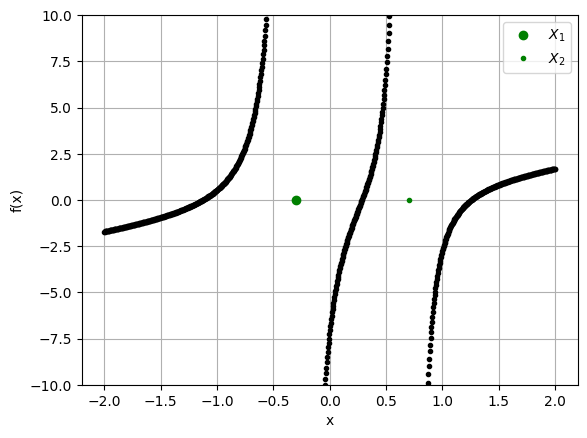

In [87]:
plt.plot(xs,fs,'k.')
plt.ylim(-10,10)
plt.plot(x1, 0, 'go', label='$X_1$')
plt.plot(x2, 0, 'g.', label='$X_2$')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()

Se usa `bisect` de `scipy.optimize` para hallar los interceptos y con esto el valor específico de los puntos de Lagrange.

`bisect` nos permite encontrar una raíz de la función en un intervalo dado, estos intervalos se escogen manualmente de acuerdo a la gráfica.

In [88]:
func_L = lambda x: funcion_puntos_colineales(x, alfa)

L1 = bisect(func_L, 0, 1 - 1.1 * alfa)
L2 = bisect(func_L, 1 - 0.9 * alfa, 2)
L3 = bisect(func_L, -2, -1.1 * alfa)

print('El punto de Lagrange L1 tiene una coordenada en el eje x de:', L1)
print('El punto de Lagrange L2 tiene una coordenada en el eje x de:', L2)
print('El punto de Lagrange L3 tiene una coordenada en el eje x de:', L3)

El punto de Lagrange L1 tiene una coordenada en el eje x de: 0.2861297820511572
El punto de Lagrange L2 tiene una coordenada en el eje x de: 1.2567346958130203
El punto de Lagrange L3 tiene una coordenada en el eje x de: -1.1232055958810359


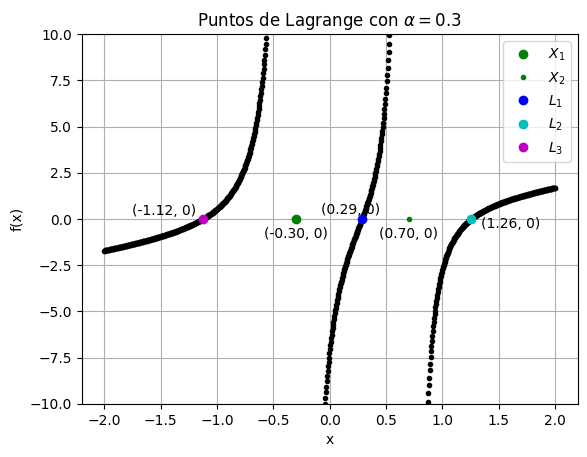

In [89]:
plt.plot(xs,fs,'k.')
plt.ylim(-10,10)

plt.plot(x1, 0, 'go', label='$X_1$')
plt.plot(x2, 0, 'g.', label='$X_2$')
plt.plot(L1, 0, 'bo', label='$L_1$')
plt.plot(L2, 0, 'co', label='$L_2$')
plt.plot(L3, 0, 'mo', label='$L_3$')

plt.text(x1, -1, f'({x1:.2f}, 0)', ha='center')
plt.text(x2, -1, f'({x2:.2f}, 0)', ha='center')
plt.text(L1-0.1, 0.3, f'({L1:.2f}, 0)', ha='center')
plt.text(L2+0.35, -0.5, f'({L2:.2f}, 0)', ha='center')
plt.text(L3-0.35, 0.2, f'({L3:.2f}, 0)', ha='center')

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Puntos de Lagrange con $\alpha = 0.3$')
plt.grid()

**3. Velocidad mínima de transferencia libre a la Luna.**

Una nave espacial se encuentra en una órbita circular alrededor de la Tierra con una altitud de 200 km y con una inclinación orbital respecto al ecuador terrestre de 28.6° (esto último garantiza que la nave espacial y la Luna se mueven sobre el mismo plano). A la nave se le dará un incremento tangencial en la velocidad, de tal manera que la órbita subsecuente sea capaz de llevarla a una órbita lunar sin variar su inclinación orbital y con el mínimo gasto de combustible posible (transferencia libre). Considerando la teoría del CRTBP, encuentre la velocidad mínima que debería tener la nave espacial (respecto al sistema rotante) requerida para este propósito. (Ayuda: calcule el valor de
$ C_J $ asociado con una partícula hipotética en reposo localizada en $L_1$).

Para este ejercicio, se parte definiendo unidades canónicas del sistema:

$$ U_L = 3.844 \times 10^8 m $$

$$ U_M = 7.348 \times 10^{22} kg + 5.97 \times 10^{24}kg $$

Donde $U_L$ corresponde al semieje mayor de la luna y $U_M$ corresponde a la masa total del sistema Tierra-Luna.

In [90]:
UL = 3.844e8
UM = 7.348e22 + pc.constantes.M_earth

Ahora se define el $α$ del sistema, por definición tenemos:

$$ α = \frac{M_{luna}}{M_{total}} $$

Y se tiene que las coordenadas son:

$$ x_1 = -α $$

$$ x_2 = 1 - α $$

In [91]:
alpha = 7.348e22 / UM
x_1 = -alpha
x_2 = 1 - alpha

print('El valor de alpha es:', alpha)
print('El valor de x1 es:', x_1)
print('El valor de x2 es:', x_2)

El valor de alpha es: 0.012154197797637198
El valor de x1 es: -0.012154197797637198
El valor de x2 es: 0.9878458022023628


Ahora, se crea una función lamba para resolver la ecuación de Jacobi:

$$ x-(1-α) \frac{x -x_1}{|x-x_1|^3} - α \frac{x -x_2}{|x-x_2|^3} = 0 $$

Luego, se hallan las raices de la función con `bisect` para conocer los puntos de Lagrange colineales.

In [92]:
funcion = lambda x:x - (1-alpha)*(x-x_1)/abs(x-x_1)**3 - alpha*(x-x_2)/abs(x-x_2)**3

In [93]:
L_1 = bisect(funcion, 0, 1-1.1*alpha)
L_2 = bisect(funcion, 1-0.9*alpha, 2)
L_3 = bisect(funcion, -2, -1.1*alpha)

print('El punto de Lagrange L1 tiene una coordenada en el eje x de:', L_1)
print('El punto de Lagrange L2 tiene una coordenada en el eje x de:', L_2)
print('El punto de Lagrange L3 tiene una coordenada en el eje x de:', L_3)

El punto de Lagrange L1 tiene una coordenada en el eje x de: 0.8368973533886037
El punto de Lagrange L2 tiene una coordenada en el eje x de: 1.1556960566047798
El punto de Lagrange L3 tiene una coordenada en el eje x de: -1.0050641508022118


Se verifica que los valores de los puntos de Lagrange sean raíces de la función, y se observa que son valores que tienden a cero.

In [94]:
print('L1 evaluado en la función:', funcion(L_1))
print('L2 evaluado en la función:', funcion(L_2))
print('L3 evaluado en la función:', funcion(L_3))

L1 evaluado en la función: -1.7693957410358507e-11
L2 evaluado en la función: 8.904377235552374e-12
L3 evaluado en la función: -4.2448215081813956e-12


Se grafica el sistema Tierra-Luna con sus respectivos puntos de Lagrange $L_1$, $L_2$ y $L_3$.

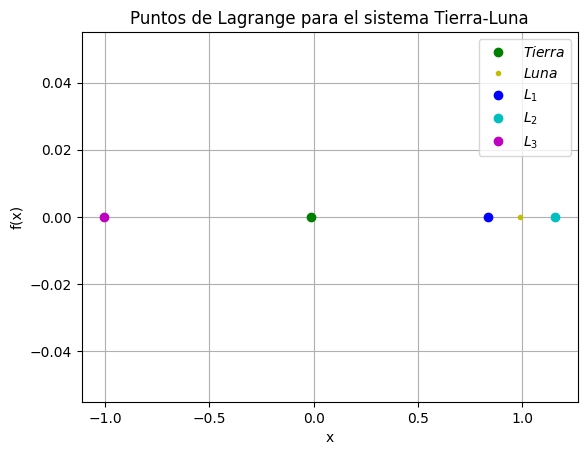

In [95]:
plt.plot(x_1, 0, 'go', label='$Tierra$')
plt.plot(x_2, 0, 'y.', label='$Luna$')
plt.plot(L_1, 0, 'bo', label='$L_1$')
plt.plot(L_2, 0, 'co', label='$L_2$')
plt.plot(L_3, 0, 'mo', label='$L_3$')

plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Puntos de Lagrange para el sistema Tierra-Luna')
plt.grid()

Luego, se halla la constante de Jacobi en unidades del sistema internacional:

$$ L_1 \cdot U_L $$

Y se transforma el $α$ de unidades canónicas al sistema internacional:

$$ α = M_{luna} \frac{UL}{UM} $$

In [96]:
L1_SI = L_1 * UL
alpha_SI = 7.348e22 * UL / UM

print('El valor de L1 en unidades del sistema internacional es:', L1_SI, 'm')
print('El valor de α en unidades del sistema internacional es:', alpha_SI, 'm')

El valor de L1 en unidades del sistema internacional es: 321703342.64257926 m
El valor de α en unidades del sistema internacional es: 4672073.633411739 m


Ahora, se reemplaza $L_1$ y $α$ en la ecuación de la constante de Jacobi:

$$ C_J = \frac{2GM_1}{r_1} + \frac{2GM_2}{r_2} + ω^2 (x^2+y^2) - v^2 $$

Además, se sabe que estos puntos de Lagrange coplanares no tienen componente en el eje z y su componente en y es cero, y el cuerpo está en reposo, por lo tanto:

$$ r_1 = \sqrt{(x + α)^2} = |x+α| $$
$$ r_2 = \sqrt{(x - 1 + α)^2} = |x-1+α| $$

De este modo, la ecuación de Jacobi queda así:

$$ C_J = \frac{2GM_1}{|x+α|} + \frac{2GM_2}{|x-1+α|} + ω^2  x^2 $$

Donde $x = L_1$ en el sistema internacional y $ω$ es la velocidad angular de la luna que se define como:

$$ ω = \frac{2\pi}{T_{sideral}} $$


In [97]:
omega_luna = 2*np.pi / (27.321661*  24 * 60 * 60 )
G  = pc.constantes.G
M_luna = 7.348e22
M_tierra = pc.constantes.M_earth

In [98]:
CJ = (2 * G * M_tierra) / abs(L1_SI + alpha_SI) + \
     (2* G * M_luna ) / abs(L1_SI -1 + alpha_SI) + \
     omega_luna**2 * L1_SI**2

print('El valor de la constante de Jacobi es:', CJ)

El valor de la constante de Jacobi es: 3205852.742524755


Por último, se calcula el potencial para que la nave logre estar a 200 km de la Tierra y que sea colineal con el centro de masa, este potencial corresponde a la suma del potencial gravitacional y el potencial centrífugo:

$$ Potencial = \frac{2GM_1}{|x+α|} + \frac{2GM_2}{|x-1+α|} + ω^2  x^2 $$

En este caso, $x = 200000$ m

In [99]:
Potencial = (2 * G * M_tierra) / abs(200000 + alpha_SI) + \
     (2* G * M_luna ) / abs(200000 -1 + alpha_SI) + \
     omega_luna**2 * 200000**2

print('El valor del potencial es:', Potencial)

El valor del potencial es: 165639810.76549864


Ahora, se resta el valor del potencial con el valor de la constante de Jacobi para obtener la velocidad mínima de la nave.

In [100]:
v_2 = Potencial - CJ
v = v_2 ** 0.5
print('La velocidad mínima de la nave es:', v)

La velocidad mínima de la nave es: 12744.958141279785


Se tiene que la velocidad mínima de la nave es de $v = 12744.96$ m/s.

**4. Constante de Jacobi como función de $\alpha$.**

Usando las herramientas computacionales provistas en clase, encuentre el valor de la constante de Jacobi correspondiente al punto de Lagrange $L_1$ para varios de valores de $\alpha$. Deduzca con los resultados obtenidos la ley semiempírica que relacione el valor de $C_J$ y $\alpha$.

Primero, se crea una función que calcule la función de Jacobi:

$$ f(x) = x-(1-α) \frac{x -x_1}{|x-x_1|^3} - α \frac{x -x_2}{|x-x_2|^3} $$

Además, la función halla el punto de Lagrange $L_1$ con bisect y lo reemplaza en la función de la constante de Jacobi (con $x=L_1$, $y=0$ y $z=0$):

$$ C_J = 2 \frac{1 - α}{r_1} + 2 \frac{α}{r_2} + (L_1)^2 $$

donde:

$$ r_1 = \sqrt{(L_1 + α)^2} = |L_1+α| $$
$$ r_2 = \sqrt{(L_1 - 1 + α)^2} = |L_1-1+α| $$


In [103]:
def Fun_Jacobi(alfa):

  x1 = -alfa
  x2 = 1-alfa

  funcion = lambda x:x - (1-alfa)*(x-x1)/abs(x-x1)**3 - alfa*(x-x2)/abs(x-x2)**3

  L1 = bisect(funcion,0,1-1.1*alfa)
  CJ = 2*(1-alfa)/abs(L1+alfa) + 2*alfa/abs(L1-1+alfa) + L1**2

  return CJ

Se le asigna valores a $α$ entre 0 y 0.2 en un arreglo de `np.linspace`, se evaluan los diferentes valores de $α$ en la función de Jacobi y se grafica $C_J$ vs $α$.

In [106]:
alfas = np.linspace(0.0001, 0.2, 100)

constantes = np.zeros(len(alfas))
for i in range(len(alfas)):
  constantes[i] = Fun_Jacobi(alfas[i])

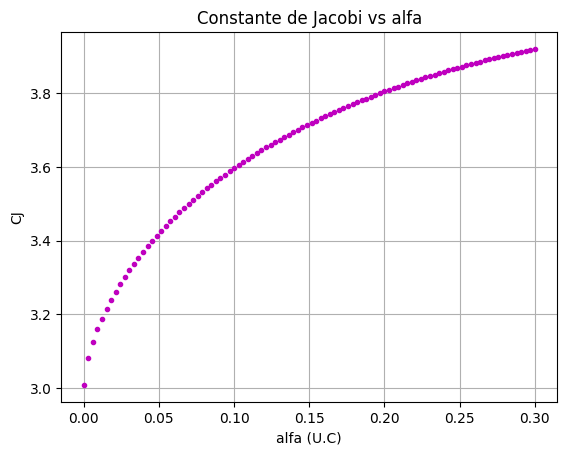

In [110]:
plt.plot(alfas, constantes, 'm.')
plt.xlabel('alfa (U.C)')
plt.ylabel('CJ')
plt.title('Constante de Jacobi vs alfa')
plt.grid()

Por último, se quiere hallar una ley semiempírica que relacione la constante de Jacobi con los valores de $α$.

Para esto, se usa la modelación con `curve fit` de `scipy.optimize`, se usan tres modelos para comprarlos:

Modelo polinómico de segundo grado:
$$ ax^2 + bx + c → C_J = aα^2 + bα +c $$

Modelo polinómico de tercer grado:
$$ ax^3 + bx^2 + cx + d → C_J = aα^3 + bα^2 +cα + d $$

Modelo raíz cuadrada:
$$ a \sqrt{x} + b → C_J = a\sqrt{α} + b $$

In [154]:
from scipy.optimize import curve_fit

def modelo_polinomico_2(x, a, b, c):
    return a*x**2 + b*x + c

def modelo_raiz(x, a, b):
    return a * np.sqrt(x) + b

def modelo_polinomico_3(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

Luego, se realiza un ajuste de curvas y predicciones de los valores de la constante de Jacobi para cada modelo.

In [155]:
# Ajuste de curvas
popt_poly2, _ = curve_fit(modelo_polinomico_2, alfas, constantes)
popt_sqrt, _ = curve_fit(modelo_raiz, alfas, constantes)
popt_poly3, _ = curve_fit(modelo_polinomico_3, alfas, constantes)

# Predicciones
CJ_poly2 = modelo_polinomico_2(alfas, *popt_poly2)
CJ_sqrt = modelo_raiz(alfas, *popt_sqrt)
CJ_poly3 = modelo_polinomico_3(alfas, *popt_poly3)

Se evalua el coeficiente de correlación $R^2$ entre los datos y los modelos propuestos.

In [156]:
def calcular_r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_poly2 = calcular_r2(constantes, CJ_poly2)
r2_sqrt = calcular_r2(constantes, CJ_sqrt)
r2_poly3 = calcular_r2(constantes, CJ_poly3)

In [160]:
print("Coeficientes modelo polinómico (grado 2):", popt_poly2)
print("R^2 polinómico (grado 2):", r2_poly2)

print("\nCoeficientes modelo raíz cuadrada:", popt_sqrt)
print("R^2 raíz cuadrada:", r2_sqrt)

print("\nCoeficientes modelo polinómico (grado 3):", popt_poly3)
print("R^2 polinómico (grado 3):", r2_poly3)

Coeficientes modelo polinómico (grado 2): [-9.21533109  5.20323802  3.1526151 ]
R^2 polinómico (grado 2): 0.9867406114315443

Coeficientes modelo raíz cuadrada: [1.69215777 3.03890889]
R^2 raíz cuadrada: 0.9900432235999459

Coeficientes modelo polinómico (grado 3): [ 41.45862052 -27.87792906   7.43301925   3.09816205]
R^2 polinómico (grado 3): 0.9962008772989994


Por último, se grafican los datos y los modelos.

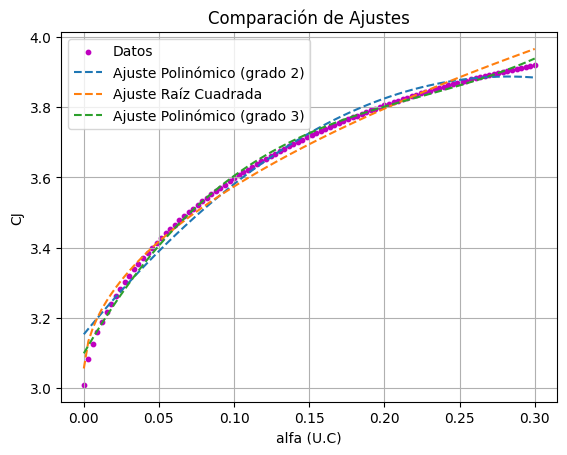

In [158]:
plt.scatter(alfas, constantes, label="Datos", color="m", s=10)
plt.plot(alfas, CJ_poly2, label="Ajuste Polinómico (grado 2)", linestyle="--")
plt.plot(alfas, CJ_sqrt, label="Ajuste Raíz Cuadrada", linestyle="--")
plt.plot(alfas, CJ_poly3, label="Ajuste Polinómico (grado 3)", linestyle="--")
plt.xlabel("alfa (U.C)")
plt.ylabel("CJ")
plt.title("Comparación de Ajustes")
plt.legend()
plt.grid()
plt.show()

Se puede concluir que los tres ajustes propuestos se adaptan muy bien a los datos originales, sin embargo, si nos basamos en los coeficientes de correlación podríamos decir que la relación entre el valor de $C_J$ y $\alpha$ es dada por un polinomio de grado 3 ($R^2 =0.996$) o una  raíz cuadrada ($R^2 =0.990$).